HousePriceML: A Machine Learning Model for California's Home Value Prediction

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
data = 'housing.csv'
df = pd.read_csv(data)

print(f'Shape: {df.shape}')
display(df.head())

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Data audit & Quality check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
#Numeric summary
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("Missing values per column:\n", missing_values)

Missing values per column:
 total_bedrooms    207
dtype: int64


In [11]:
# category counts
print("Category counts for 'ocean_proximity':\n", df['ocean_proximity'].value_counts())

Category counts for 'ocean_proximity':
 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Explanatory Data Analysis

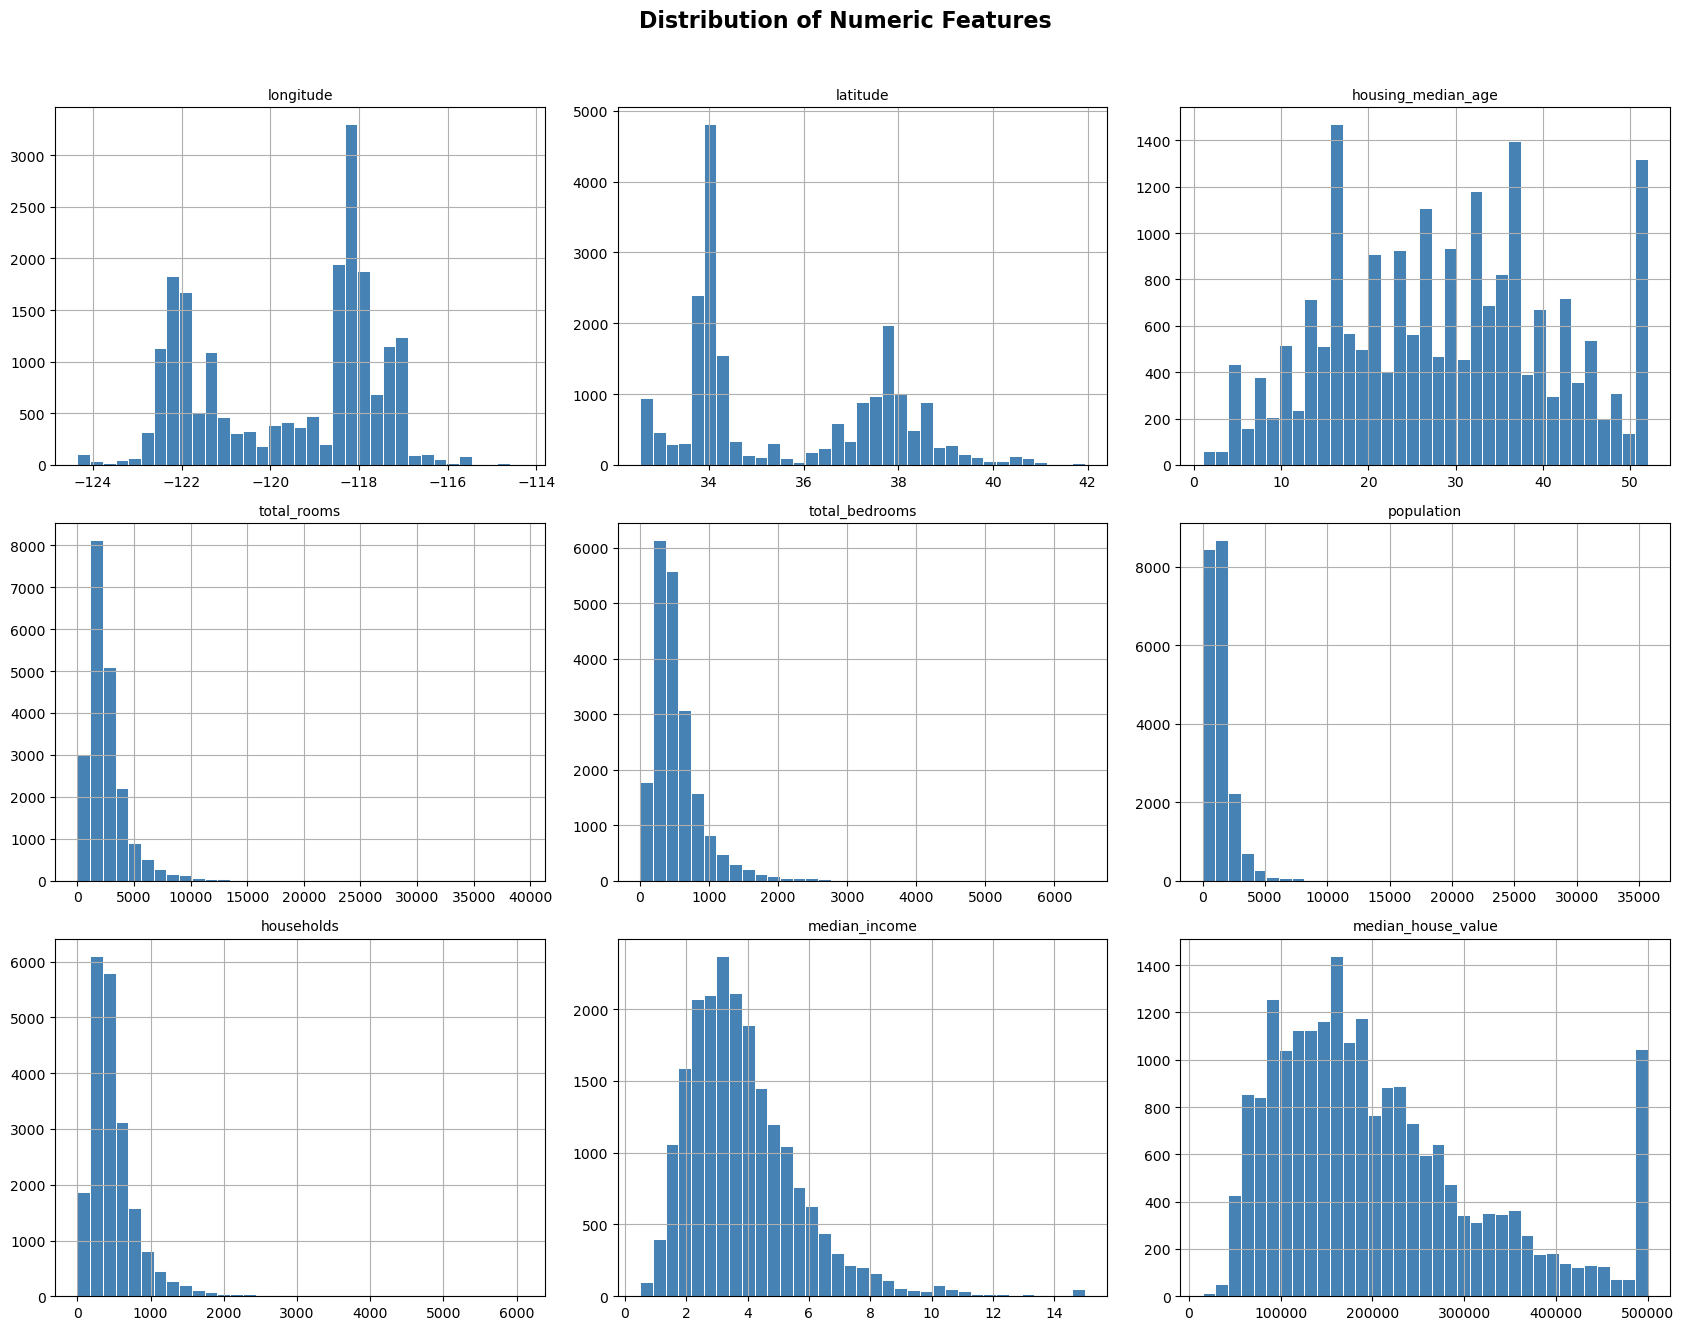

In [15]:
#Distribution overview for numeric features
axes = df.hist(
    bins=35, 
    figsize=(17, 13), 
    edgecolor= "white", 
    color= "steelblue", 
    linewidth=0.7)

# Adjust layout
for axe in axes.flatten():
    axe.set_title(axe.get_title(), fontsize=10)
    axe.set_xlabel(axe.get_xlabel(), fontsize=8)
    axe.set_ylabel(axe.get_ylabel(), fontsize=8)

plt.suptitle('Distribution of Numeric Features', fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

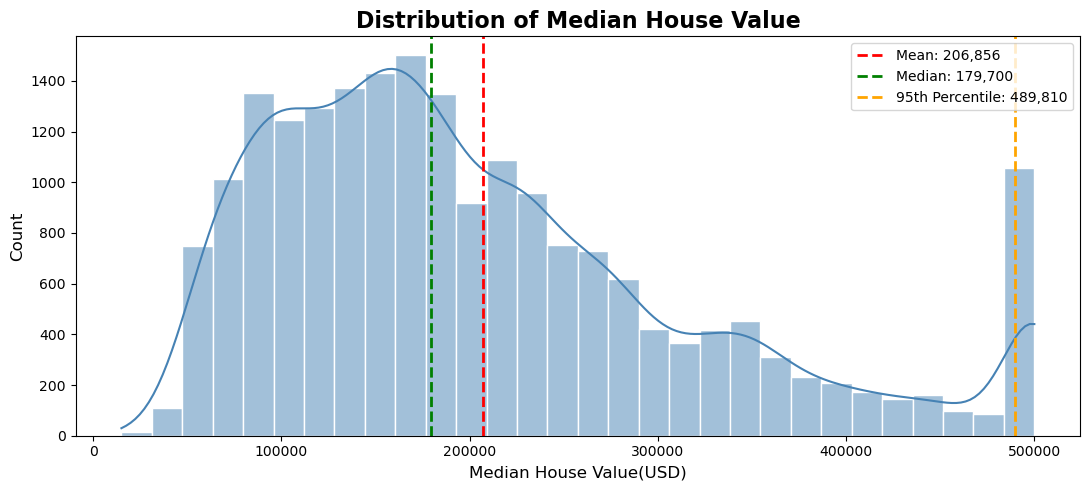

In [18]:
#target distribution with central tendency and tails indicators
target = df['median_house_value']
q95 = target.quantile(0.95)

plt.figure(figsize=(11, 5))
sns.histplot(target, bins=30, kde=True, color='steelblue', edgecolor='white')
plt.axvline(target.mean(), color='red', linestyle='--', linewidth=2, label= f"Mean: {target.mean():,.0f}")
plt.axvline(target.median(), color='green', linestyle='--', linewidth=2, label= f"Median: {target.median():,.0f}")
plt.axvline(q95, color='orange', linestyle='--', linewidth=2, label= f"95th Percentile: {q95:,.0f}")
plt.title('Distribution of Median House Value', fontsize=16, fontweight="bold")
plt.xlabel('Median House Value(USD)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

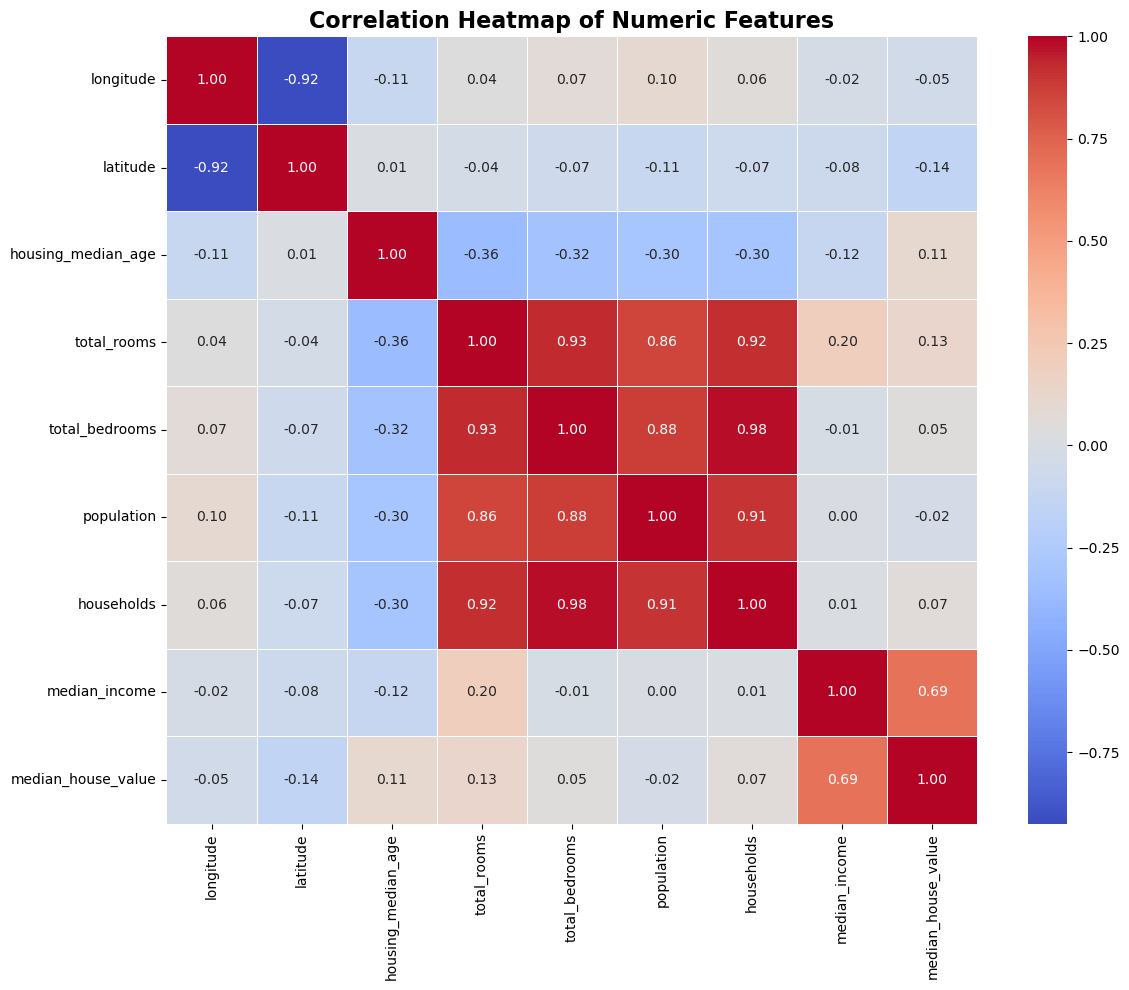

Correlation of features with median_house_value:
 median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [23]:
# correlation heatmap for numeric features
numeric_features = df.select_dtypes(include=[np.number])
corr = numeric_features.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

correlation_with_target = corr["median_house_value"].sort_values(ascending=False)
print("Correlation of features with median_house_value:\n", correlation_with_target)

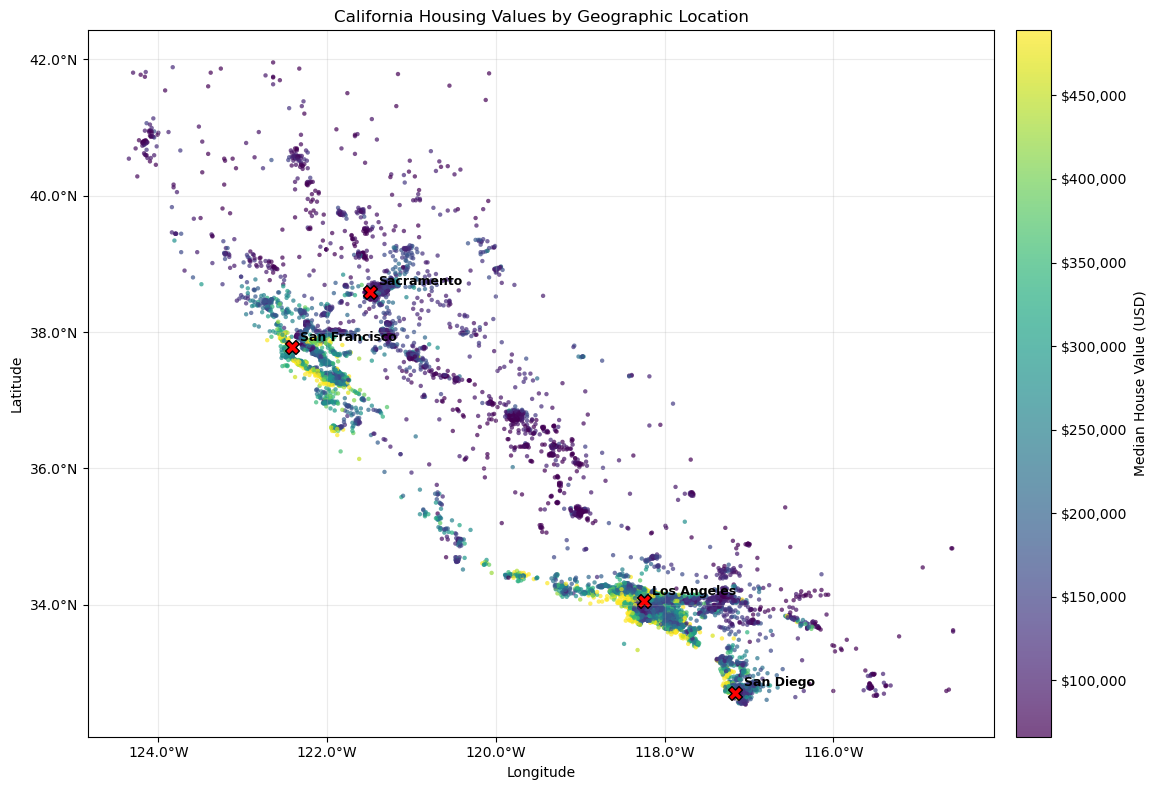

In [33]:
#geo-spatial distribution of house values

from matplotlib.ticker import FuncFormatter

plot_df = df.sample(min(10000, len(df)), random_state=42).copy()

vmin = plot_df['median_house_value'].quantile(0.05)
vmax = plot_df['median_house_value'].quantile(0.95)

fig, axe = plt.subplots(figsize=(12, 8))

sc = axe.scatter(
    plot_df['longitude'],
    plot_df['latitude'],
    c=plot_df['median_house_value'],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    s=10,
    edgecolors='none'
)

cities = {
    'San Francisco': (-122.4194, 37.7749),
    'Los Angeles': (-118.2437, 34.0522),
    'San Diego': (-117.1611, 32.7157),
    'Sacramento': (-121.4944, 38.5816)
}

for city, (lon, lat) in cities.items():
    axe.scatter(lon, lat, color='red', marker='X', s=100, edgecolors='black')
    axe.text(lon + 0.1, lat + 0.1, city, fontsize=9, fontweight='bold')

axe.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{abs(x):.1f}°{'W' if x < 0 else 'E'}")
)
axe.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y:.1f}°N")
)

cbar = plt.colorbar(sc, ax=axe, pad=0.02)
cbar.set_label('Median House Value (USD)')
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, pos: f"${v:,.0f}")
)

axe.set_xlabel('Longitude')
axe.set_ylabel('Latitude')
axe.set_title('California Housing Values by Geographic Location')
axe.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

C:\Users\lenev\AppData\Local\Temp\ipykernel_388\1917692118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ocean_proximity',


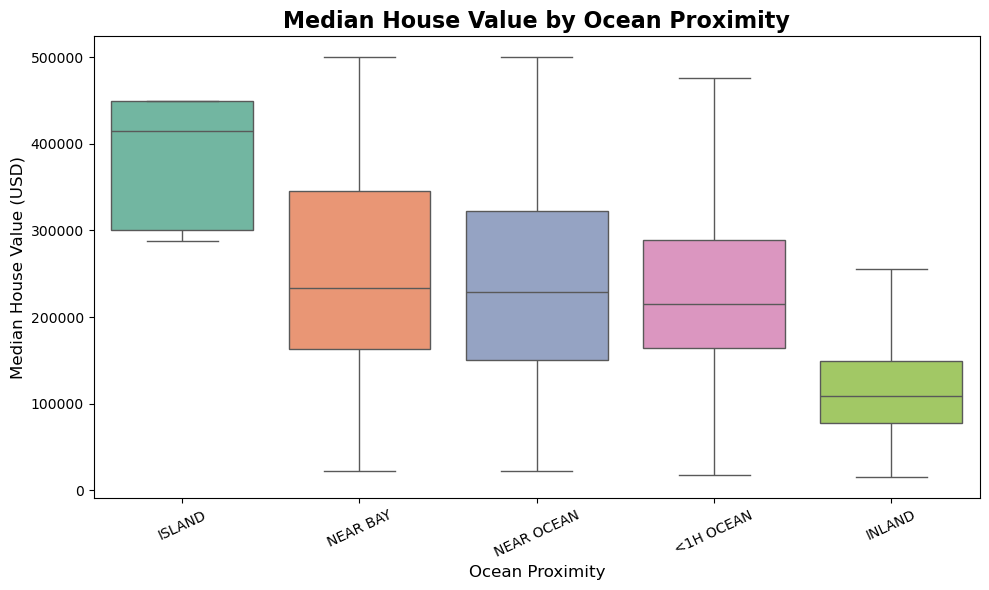

In [38]:
#target distribution by ocean proximity
segmentation = (df.groupby('ocean_proximity')['median_house_value']
                .median().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', 
            y='median_house_value', 
            data=df, 
            order=segmentation,
            showfliers=False, 
            palette='Set2')

plt.title('Median House Value by Ocean Proximity', fontsize=16, fontweight="bold")
plt.xlabel('Ocean Proximity', fontsize=12)
plt.ylabel('Median House Value (USD)', fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.model_selection import train_test_split

model_df = df.copy()

#to avoid division by zero issues, we use NaN safe denominator
room_safe = model_df["total_rooms"].replace(0, np.nan)
household_safe = model_df["households"].replace(0, np.nan)
population_safe = model_df["population"].replace(0, np.nan)

#geo-spatial interaction features
model_df["latitude*longitude"] = model_df["latitude"] * model_df["longitude"]
model_df["latitude+longitude"] = model_df["latitude"] + model_df["longitude"]

#ratio features
model_df["rooms_per_household"] = room_safe / household_safe
model_df["population_per_household"] = population_safe / household_safe
model_df["bedrooms_per_room"] = model_df["total_bedrooms"] / room_safe
model_df["bedrooms_per_household"]= model_df["total_bedrooms"] / household_safe
model_df["rooms_per_person"] = room_safe / population_safe

#income density features
model_df["income_per_household_member"] = model_df["median_income"] / model_df["population_per_household"]
model_df["income*rooms_per_household"] = model_df["median_income"] * model_df["rooms_per_household"]

#log transformations skewed counts features
for column in ["total_rooms", "total_bedrooms", "population", "households"]:
    model_df[f"log_{column}"] = np.log1p(model_df[column])

# Define features and target
X = model_df.drop("median_house_value", axis=1)
Y = model_df["median_house_value"]

#split dataset into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split( 
    X, Y, test_size=0.2, random_state=42)

#identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 21
Categorical features: 1


PREPROCESSING

In [46]:
#Building preprocessing pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                   ("scaler", StandardScaler())])

categorical_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                        ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

preprocessing_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income',
                                  'latitude*longitude', 'latitude+longitude',
                                  'rooms_per_household',
                                  'population_per_household',
                                  'bedrooms_per_room', 'bedrooms_per_household',
                                  'rooms_per_person',
                                  'income_per_household_member',
                                  'income*rooms_per_household',
                                  'log_total_rooms', 'log_total_bedrooms',
                                  'log_population', 'log_households']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])